In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

Used Datasets:

https://huggingface.co/datasets/aelhalili/bash-commands-dataset -> 680 rows
https://huggingface.co/datasets/emirkaanozdemr/bash_command_data_6K -> 6.153 rows
https://huggingface.co/datasets/westenfelder/NL2SH-ALFA -> 40,939 rows

In [ ]:
dataset1 = load_dataset("aelhalili/bash-commands-dataset")
dataset1 = pd.DataFrame(dataset1["train"])
dataset1.head()

README.md:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

dataset.json:   0%|          | 0.00/91.5k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

,prompt,response
0,Move a file called x from the Desktop to the D...,mv ~/Desktop/x ~/Downloads/
1,Open YouTube and search for videos by Mr Beast,xdg-open 'https://www.youtube.com/results?sear...
2,Create a folder named projects inside the Docu...,mkdir ~/Documents/projects
3,Open the Firefox browser,firefox &
4,Search for all PNG files in the Pictures folder,find ~/Pictures -name '*.png'


In [ ]:
dataset2 = load_dataset("emirkaanozdemr/bash_command_data_6K")
dataset2 = pd.DataFrame(dataset2["train"])
dataset2.head()

README.md:   0%|          | 0.00/2.88k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/476k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6153 [00:00<?, ? examples/s]

,prompt,completion
0,"List all files in the current directory, inclu...",ls -la
1,"Show the first 10 lines of a file named ""repor...",head -n 10 report.txt
2,"Count how many times the word ""error"" appears ...","grep -o ""error"" /var/log/syslog | wc -l"
3,Create a compressed tar archive named backup.t...,tar -czvf backup.tar.gz /home/user/data
4,Find all .log files larger than 5 MB in /var/l...,"find /var/log -type f -name ""*.log"" -size +5M ..."


In [ ]:
dataset3 = load_dataset("westenfelder/NL2SH-ALFA", "train")
print(dataset3)
dataset3 = pd.DataFrame(dataset3["train"])
dataset3.head()

README.md:   0%|          | 0.00/4.76k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/4.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40639 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['nl', 'bash'],
        num_rows: 40639
    })
})


,nl,bash
0,show the free space on all filesystems,df -h
1,lists the name and pids of the top 5 processes...,"ps -eo pid,comm,%cpu --sort=-%cpu | head -n 6"
2,shows how much free memory a system has,free -h
3,shows how much free space there is on the root...,df -h /
4,shows the disk space used by the directory /va...,du -sh /var/log


In [ ]:
dataset1 = dataset1.rename(columns={'response': 'command'})
dataset2 = dataset2.rename(columns={'completion': 'command'})
dataset3 = dataset3.rename(columns={'nl': 'prompt', 'bash': 'command'})

df = pd.concat([dataset1,dataset2,dataset3])
print("Total Dataset Shape: ",df.shape)
df.head()

Total Dataset Shape:  (47632, 2)


,prompt,command
0,Move a file called x from the Desktop to the D...,mv ~/Desktop/x ~/Downloads/
1,Open YouTube and search for videos by Mr Beast,xdg-open 'https://www.youtube.com/results?sear...
2,Create a folder named projects inside the Docu...,mkdir ~/Documents/projects
3,Open the Firefox browser,firefox &
4,Search for all PNG files in the Pictures folder,find ~/Pictures -name '*.png'


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47632 entries, 0 to 40638
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   prompt   47632 non-null  object
 1   command  47632 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum().sort_values()

,0
prompt,0
command,0


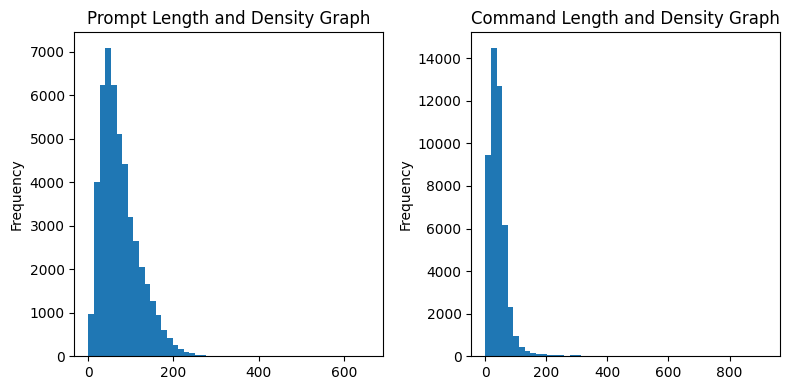

In [ ]:
df["prompt_length"] = df["prompt"].apply(len)
df["command_length"] = df["command"].apply(len)

fig, axs = plt.subplots(1,2, figsize=(8,4))

df["prompt_length"].plot(kind="hist", bins=50, title="Prompt Length and Density Graph", ax=axs[0])
df["command_length"].plot(kind="hist", bins=50, title="Command Length and Density Graph", ax=axs[1])
plt.tight_layout()

In [ ]:
print(f"Shortest Prompt Length: {df["prompt_length"].sort_values(ascending=True).iloc[0]}")
print(f"Longest Prompt Length: {df["prompt_length"].sort_values(ascending=False).iloc[0]}")
print(f"Shortest Command Length: {df["command_length"].sort_values(ascending=True).iloc[0]}")
print(f"Longest Command Length: {df["command_length"].sort_values(ascending=False).iloc[0]}")

Shortest Prompt Length: 1
Longest Prompt Length: 659
Shortest Command Length: 1
Longest Command Length: 919


In [ ]:
df = df[df['command'].str.strip() != ""]
df = df[df['prompt'].str.strip() != ""]
df = df[df['prompt'] != df['command']]

In [ ]:
df = df[df["command_length"] <= 200]
df = df[df["prompt_length"] <= 200]

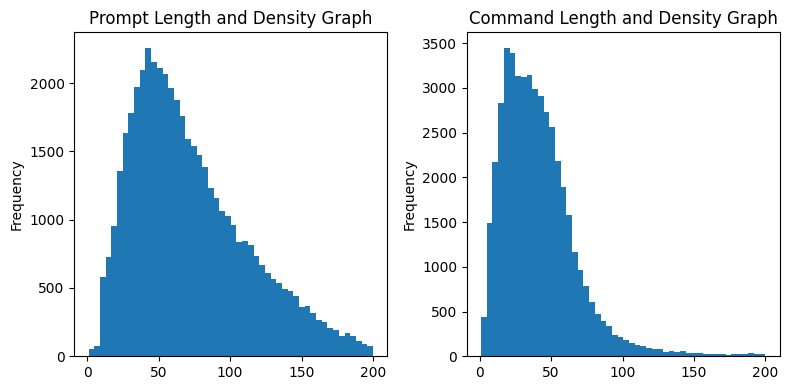

In [ ]:
df["prompt_length"] = df["prompt"].apply(len)
df["command_length"] = df["command"].apply(len)

fig, axs = plt.subplots(1,2, figsize=(8,4))

df["prompt_length"].plot(kind="hist", bins=50, title="Prompt Length and Density Graph", ax=axs[0])
df["command_length"].plot(kind="hist", bins=50, title="Command Length and Density Graph", ax=axs[1])
plt.tight_layout()

In [ ]:
print("New Dataset Shape: ",df.shape)
print("New Dataset: ",df.head())

New Dataset Shape:  (46563, 4)
New Dataset:                                                prompt  \
0  Move a file called x from the Desktop to the D...   
1     Open YouTube and search for videos by Mr Beast   
2  Create a folder named projects inside the Docu...   
3                           Open the Firefox browser   
4    Search for all PNG files in the Pictures folder   

                                             command  prompt_length  \
0                        mv ~/Desktop/x ~/Downloads/             64   
1  xdg-open 'https://www.youtube.com/results?sear...             46   
2                         mkdir ~/Documents/projects             61   
3                                          firefox &             24   
4                      find ~/Pictures -name '*.png'             47   

   command_length  
0              27  
1              64  
2              26  
3               9  
4              29  


# Data Processing

In [ ]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from datasets import Dataset

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [ ]:
slang_dict = {
    r'\bidk\b': 'i do not know',
    r'\bnvm\b': 'nevermind',
    r'\bur\b': 'you are',
    r'\bnah\b': 'no',
    r'\bnaw\b': 'no',
    r'\bok\b': 'okay',
    r'\bsh\*\*\b': 'shit'
}

def clean_and_lemmatize(text):
    text = text.lower().strip()

    for pattern, replacement in slang_dict.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokenlar = word_tokenize(text)

    temiz_tokenlar = [
        lemmatizer.lemmatize(token)
        for token in tokenlar
        if token.isalnum() and token not in stop_words
    ]

    return " ".join(temiz_tokenlar)

In [ ]:
df["clean_prompt"] = df["prompt"].apply(clean_and_lemmatize)
df["clean_prompt"].head()

,clean_prompt
0,move file called x desktop downloads directory
1,open youtube search video mr beast
2,create folder named project inside document di...
3,open firefox browser
4,search png file picture folder


In [ ]:
df.shape

(46563, 5)

In [ ]:
def clean_bash_command(command):
    if not isinstance(command, str):
        return ""

    command = command.strip().replace('\n', ' ').replace('\t', ' ')

    command = re.sub(r'\s+', ' ', command)
    return command

In [ ]:
df['clean_command'] = df['command'].apply(clean_bash_command)
df["clean_command"]

,clean_command
0,mv ~/Desktop/x ~/Downloads/
1,xdg-open 'https://www.youtube.com/results?sear...
2,mkdir ~/Documents/projects
3,firefox &
4,find ~/Pictures -name '*.png'
...,...
40634,cat report.txt
40635,cat directory/* | grep -v '.zip'
40636,unzip documents.zip -x '*.doc'
40637,touch memo.txt


In [ ]:
print("New Longest Command:", df['clean_command'].str.len().max())
print("New shape of data: ",df.shape)

New Longest Command: 200
New shape of data:  (46563, 6)


convert pd.DataFrame to Dataset.from_pandas

In [ ]:
dataset = Dataset.from_pandas(df[["clean_prompt","clean_command"]])

dataset_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split['train']
val_dataset = dataset_split['test']

In [ ]:
train_dataset.to_csv("clean_train.csv")
val_dataset.to_csv("clean_val.csv")

Creating CSV from Arrow format:   0%|          | 0/38 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

893947

# Text Tokenization

In [ ]:
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, AutoTokenizer, DataCollatorForSeq2Seq

In [ ]:
model_name = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    inputs = ["translate English to Bash: " + doc for doc in examples["clean_prompt"]]
    targets = [targets for targets in examples["clean_command"]]

    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding=False)

    labels = tokenizer(text_target=targets, max_length=192, truncation=True, padding=False)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Map:   0%|          | 0/37250 [00:00<?, ? examples/s]

Map:   0%|          | 0/9313 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=None)

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

training_args = Seq2SeqTrainingArguments(
    output_dir="./bash_t5_results",
    eval_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=9,
    predict_with_generate=True,
    fp16=True,
    logging_steps=100
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,2.763700,2.451427
2,2.519056,2.218314
3,2.331814,2.101909
4,2.276055,2.027273
5,2.191777,1.978914
6,2.186462,1.947009
7,2.118185,1.924633
8,2.081967,1.912875
9,2.113884,1.909557


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10485, training_loss=2.3504636881859686, metrics={'train_runtime': 1546.733, 'train_samples_per_second': 216.747, 'train_steps_per_second': 6.779, 'total_flos': 2526495722373120.0, 'train_loss': 2.3504636881859686, 'epoch': 9.0})

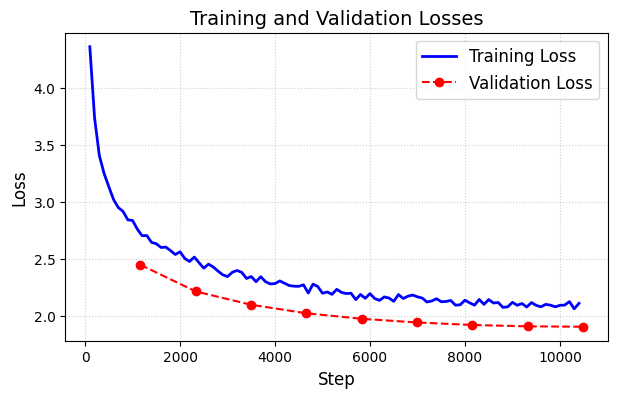

In [ ]:
history = pd.DataFrame(trainer.state.log_history)

train_loss_df = history[history['loss'].notna()]
eval_loss_df = history[history['eval_loss'].notna()]

plt.figure(figsize=(7, 4))

plt.plot(train_loss_df['step'], train_loss_df['loss'], label='Training Loss', color='blue', linewidth=2)

if not eval_loss_df.empty:
    plt.plot(eval_loss_df['step'], eval_loss_df['eval_loss'], label='Validation Loss', color='red', linestyle='--', marker='o')

plt.title('Training and Validation Losses', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

In [ ]:
import shutil
from google.colab import files

model.save_pretrained("./my_model")
tokenizer.save_pretrained("./my_model")

shutil.make_archive("my_model", "zip", "my_model")
files.download("my_model.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Test Model

In [ ]:
def generate_bash(prompt):
    input_text = "translate English to Bash: " + prompt
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_length=128)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
test_prompts = [
    # 1. Dosya ve Dizin İşlemleri (Temel)
    "create a directory named test_folder",
    "remove file secret.txt without confirmation",
    "change current directory to /var/log",
    "copy file data.csv to backup folder",
    "rename old.txt to new.txt",

    # 2. Listeleme ve Arama (Orta Seviye)
    "list all files including hidden ones",
    "find all .log files in the current directory",
    "search for the word 'error' in app.log",
    "show the first 10 lines of system.log",

    # 3. Sistem ve Ağ Bilgisi (Spesifik Parametreler)
    "display current working directory",
    "show disk space usage in human readable format",
    "display active network connections",
    "print the current date and time"
]

# Döngüye sokarak test etme
print(f"{'PROMPT':<50} | {'ÜRETİLEN BASH KOMUTU'}")
print("-" * 85)

for prompt in test_prompts:
    predicted_cmd = generate_bash(prompt)
    print(f"{prompt:<50} | {predicted_cmd}")

PROMPT                                             | ÜRETİLEN BASH KOMUTU
-------------------------------------------------------------------------------------
create a directory named test_folder               | mkdir test_folder
remove file secret.txt without confirmation        | rm secret.txt
change current directory to /var/log               | find. -type d -name '*.log' -exec chmod /var/log  ;
copy file data.csv to backup folder                | cp data.csv /var/log/
rename old.txt to new.txt                          | rename old.txt to new.txt
list all files including hidden ones               | ls -l
find all .log files in the current directory       | find. -type f -name '*.log' -exec grep -l '' ;
search for the word 'error' in app.log             | grep -l "error"
show the first 10 lines of system.log              | syslog -l 10
display current working directory                  | find $(pwd)
show disk space usage in human readable format     | df -l /dev/sdisk
display active

# Memory Usage View

In [ ]:
import torch

if torch.cuda.is_available():
    max_allocated = torch.cuda.max_memory_allocated() / (1024 ** 3)
    print(f"Biten eğitimde ulaşılan en yüksek GPU bellek kullanımı: {max_allocated:.2f} GB")
else:
    print("GPU aktif değil veya bağlantı kesilmiş.")

Biten eğitimde ulaşılan en yüksek GPU bellek kullanımı: 4.71 GB


In [ ]:
!nvidia-smi

Wed Jul  8 08:56:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             38W /   70W |   10529MiB /  15360MiB |     20%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvidia-smi --query-gpu=memory.total --format=csv

memory.total [MiB]
15360 MiB
